# Table of Contents

1. Problem Understanding  
2. Import Libraries  
3. Load Dataset  
4. Basic Data Inspection  
5. Data Cleaning  
6. Exploratory Data Analysis  
7. Feature Engineering for ML  
8. Train-Test Split  
9. TF-IDF Vectorization  
10. Baseline Model  
11. Logistic Regression  
12. Naive Bayes  
13. Decision Tree  
14. Hyperparameter Tuning  
15. KNN  
16. Model Comparison  
17. Content-Based Recommendation System  
18. User-Item Matrix  
19. Matrix Factorization using NMF  
20. New User Recommendation System  
21. Final Conclusion


# 1. Problem Understanding

This project has two main goals.

## Goal 1: Machine Learning Classification
We will predict whether Netflix content is a **Movie** or **TV Show**.

- Input features: title, genre, description
- Target: type

## Goal 2: Recommendation System
We will recommend movies/shows based on user preferences.

We will build:

- Content-based recommender
- Synthetic user-item matrix
- Matrix factorization recommender
- New user recommender

This Netflix dataset does not contain real user ratings. So, for matrix factorization, we create synthetic user ratings for learning purposes.

# 2. Import Libraries

We import all important Python libraries used for data analysis, visualization, machine learning, and recommendation systems.


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for clean notebook output
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# 3. Load Dataset

We load the Netflix dataset.


In [2]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 4. Basic Data Inspection

Before cleaning or modeling, we first understand the dataset structure.


In [3]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Rows and Columns: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [5]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [6]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# 5. Data Cleaning

Machine learning models do not work well with missing values or inconsistent data.

We will:

- Fill missing text values with `Unknown`
- Fill missing rating and duration using mode
- Convert date column into datetime format
- Create new date features


In [7]:
# Fill missing text values
for col in ["director", "cast", "country"]:
    df[col] = df[col].fillna("Unknown")

# Fill missing categorical values with most common value
for col in ["rating", "duration", "date_added"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
print(df.isnull().sum())


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [8]:
# Convert date_added into datetime format
# errors='coerce' converts invalid dates into NaT instead of crashing

df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    errors="coerce"
)

# Fill any failed date conversions with the most common valid date
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

# Extract year and month added
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df[["date_added", "year_added", "month_added"]].head()


,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [9]:
print("Final Shape:", df.shape)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape: (8807, 14)

Missing Values After Cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64


### Cleaning Summary: Missing values are handled, dates are converted, and new date features are created.



# 6. Exploratory Data Analysis (EDA)

EDA helps us understand patterns in Netflix content. For each chart, think: **Question → Visualization → Insight**.


## 6.1 Movies vs TV Shows

**Question:** Which content type dominates Netflix?


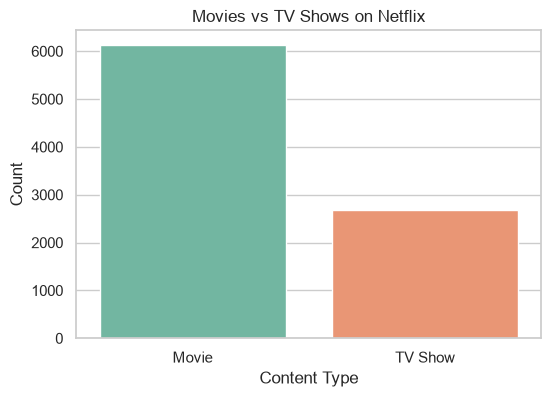

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="type", palette="Set2")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

df["type"].value_counts()


**Insight:** Netflix contains more Movies than TV Shows. Movies dominate the platform library.


## 6.2 Content Rating Distribution

**Question:** Which audience rating is most common?


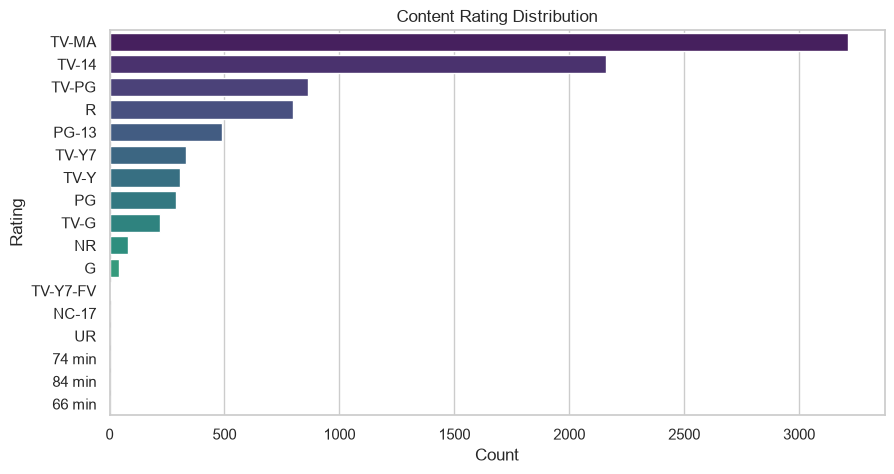

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index,
    palette="viridis"
)
plt.title("Content Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

df["rating"].value_counts().head(10)


**Insight:** TV-MA and TV-14 are among the most common ratings, showing that Netflix has many titles for mature and teen audiences.

## 6.3 Top 10 Countries

**Question:** Which countries contribute the most Netflix content?


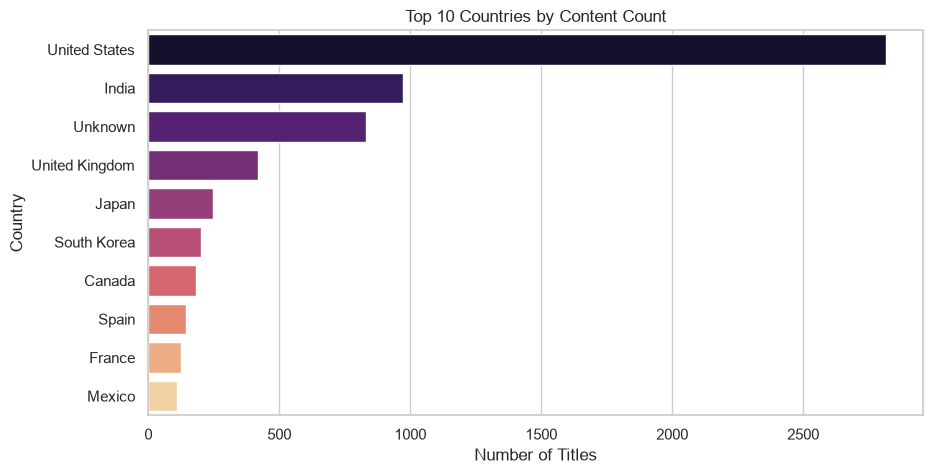

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [12]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

top_countries

**Insight:** The United States contributes the highest number of Netflix titles, followed by countries such as India and the United Kingdom.

## 6.4 Release Year Distribution

**Question:** How has content production changed over time?

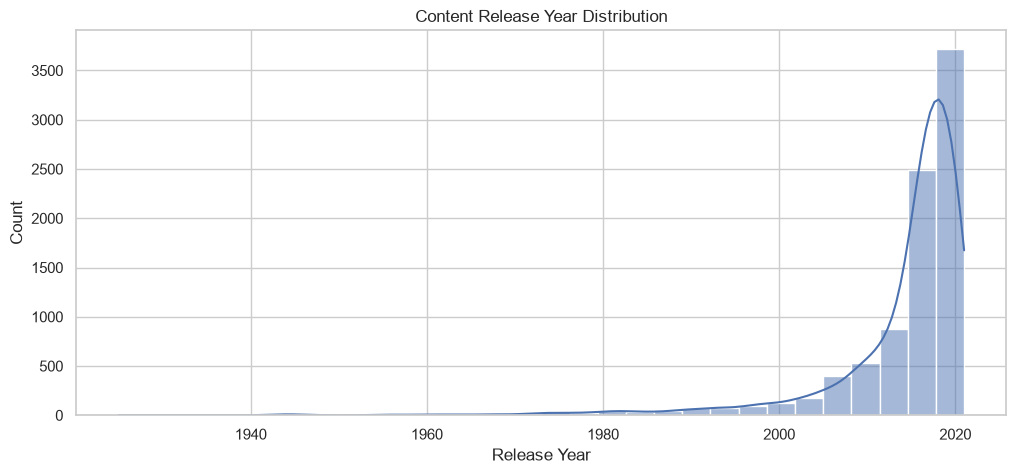

In [13]:
plt.figure(figsize=(12, 5))
sns.histplot(df["release_year"], bins=30, kde=True)
plt.title("Content Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

**Insight:** Most titles were released after 2000, with strong growth after 2010.

## 6.5 Content Added by Year

**Question:** When did Netflix add the most content?

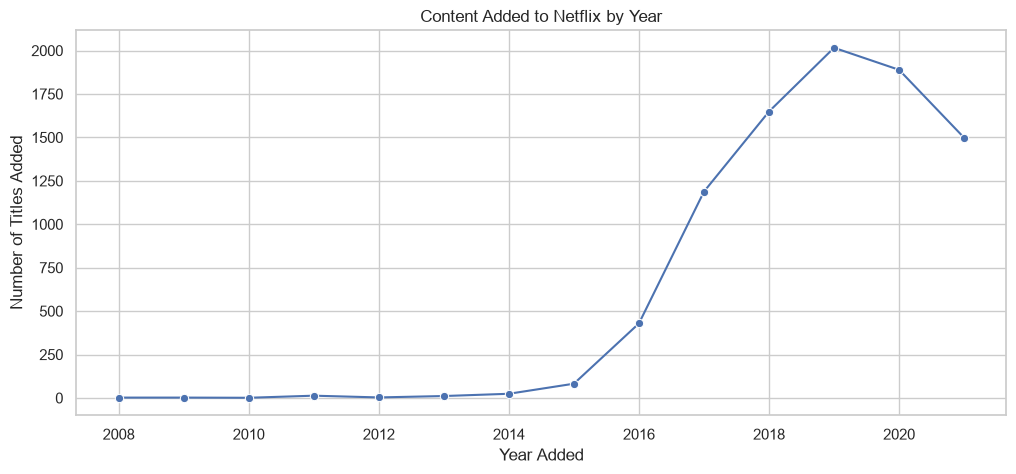

In [14]:
year_added = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=year_added.index, y=year_added.values, marker="o")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.show()

**Insight:** Netflix expanded aggressively after 2015, with a peak around 2019.

## 6.6 Movie vs TV Show Release Trend

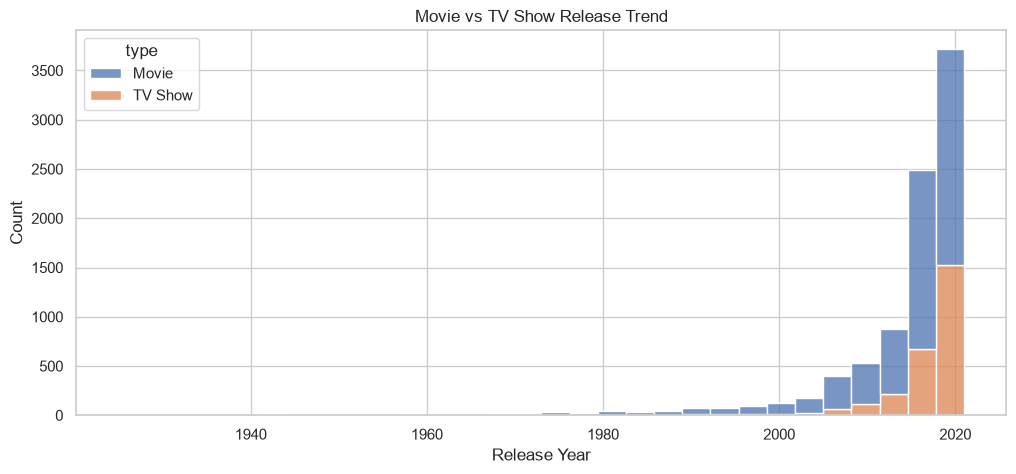

In [15]:
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df,
    x="release_year",
    hue="type",
    bins=30,
    multiple="stack"
)
plt.title("Movie vs TV Show Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

## 6.7 Movie Duration Analysis

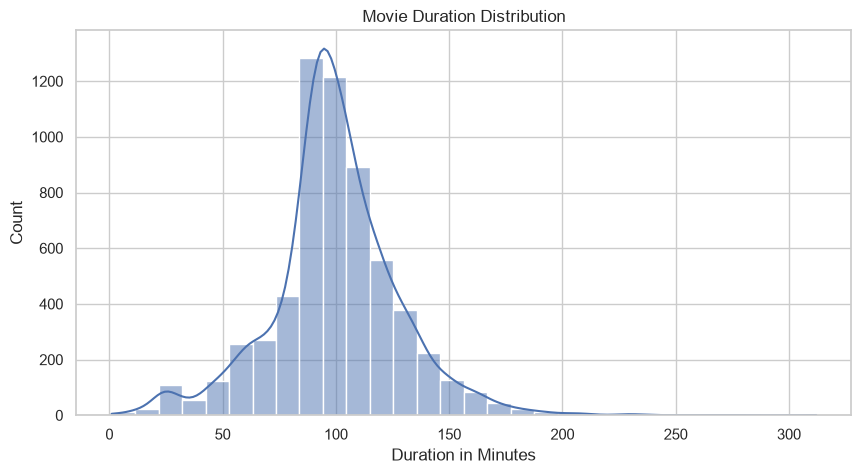

In [16]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_num"] = movies["duration"].str.extract(r"(\d+)").astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(movies["duration_num"], bins=30, kde=True)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Count")
plt.show()

**Insight:** Most Netflix movies are around 80 to 120 minutes long.

## 6.8 Genre Analysis

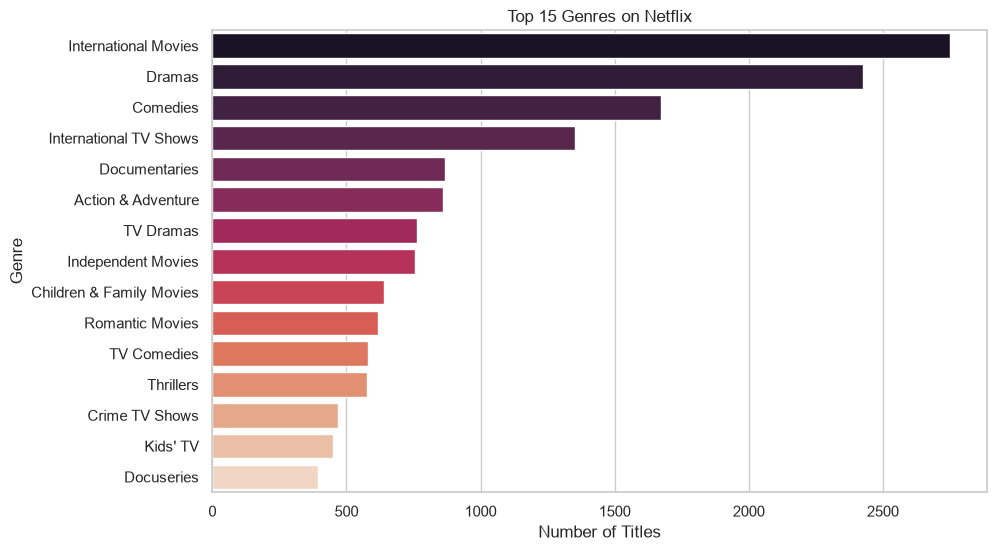

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

In [17]:
genre_counts = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="rocket")
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

genre_counts


**Insight:** International Movies, Dramas, and Comedies are major genres in Netflix content.

## 6.9 Word Cloud from Descriptions


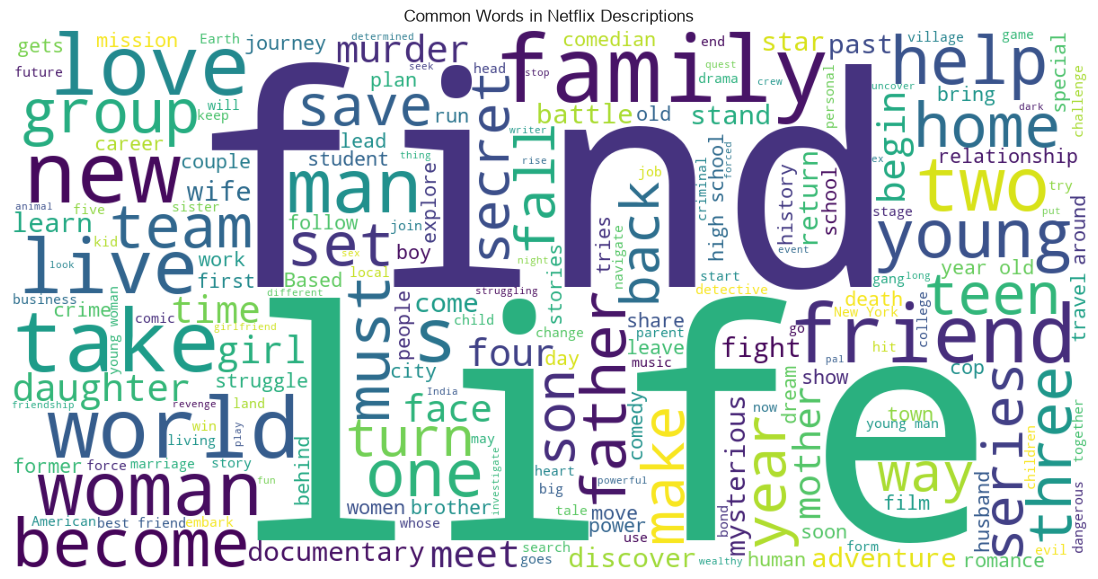

In [18]:
try:
    from wordcloud import WordCloud

    text = " ".join(df["description"].astype(str))

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title("Common Words in Netflix Descriptions")
    plt.show()
except ImportError:
    print("wordcloud is not installed. Run: pip install wordcloud")


## EDA Summary

Key findings:

1. Movies dominate Netflix content.
2. TV-MA and TV-14 are very common ratings.
3. The United States contributes the most content.
4. Most titles were released after 2000.
5. Netflix added a large amount of content after 2015.
6. Most movies are 80–120 minutes long.
7. International Movies, Dramas, and Comedies are dominant genres.


# 7. Feature Engineering for Machine Learning

We combine title, genre, and description into one text column. This gives the ML model more information.

In [19]:
df["text"] = (
    df["title"].astype(str)
    + " "
    + df["listed_in"].astype(str)
    + " "
    + df["description"].astype(str)
)

# Convert target labels into numbers
# Movie = 0, TV Show = 1

df["target"] = df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

df[["type", "target", "text"]].head()

,type,target,text
0,Movie,0,Dick Johnson Is Dead Documentaries As her fath...
1,TV Show,1,"Blood & Water International TV Shows, TV Drama..."
2,TV Show,1,"Ganglands Crime TV Shows, International TV Sho..."
3,TV Show,1,"Jailbirds New Orleans Docuseries, Reality TV F..."
4,TV Show,1,"Kota Factory International TV Shows, Romantic ..."


# 8. Train-Test Split

We split data into training and testing sets. This helps us check whether the model performs well on unseen data.

In [20]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (7045,)
Testing size: (1762,)


# 9. TF-IDF Vectorization

Machine learning models cannot understand raw text. TF-IDF converts text into numerical features.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Train TF-IDF shape: (7045, 5000)
Test TF-IDF shape: (1762, 5000)


# 10. Baseline Model

A baseline model gives us a minimum score to beat. Here, the baseline always predicts the most common class.

In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_tfidf, y_train)
baseline_pred = baseline.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.6963677639046538


# 11. Logistic Regression

Logistic Regression is a strong and simple model for classification tasks.

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)
lr_probs = lr.predict_proba(X_test_tfidf)[:, 1]
lr_roc_auc = roc_auc_score(y_test, lr_probs)

print("Logistic Regression Accuracy:", lr_acc)
print("ROC AUC:", lr_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9903518728717366
ROC AUC: 0.9998171971756964

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1227
           1       1.00      0.97      0.98       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



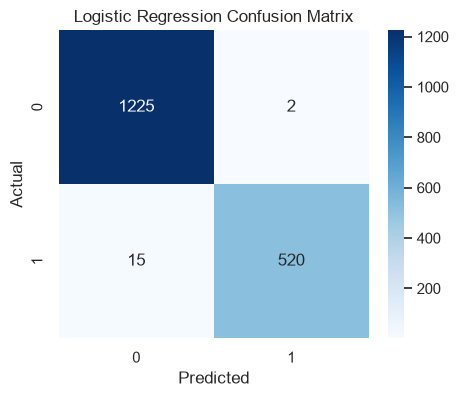

In [24]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Naive Bayes

Naive Bayes works very well for text classification because it is based on word probabilities.

In [25]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, nb_pred)
nb_probs = nb.predict_proba(X_test_tfidf)[:, 1]
nb_roc_auc = roc_auc_score(y_test, nb_probs)

print("Naive Bayes Accuracy:", nb_acc)
print("ROC AUC:", nb_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.963677639046538
ROC AUC: 0.9961535239052777

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1227
           1       0.99      0.89      0.94       535

    accuracy                           0.96      1762
   macro avg       0.97      0.94      0.96      1762
weighted avg       0.97      0.96      0.96      1762



# 13. Decision Tree

Decision Tree learns simple decision rules from the TF-IDF features.

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)
dt_pred = dt.predict(X_test_tfidf)

dt_acc = accuracy_score(y_test, dt_pred)
dt_probs = dt.predict_proba(X_test_tfidf)[:, 1]
dt_roc_auc = roc_auc_score(y_test, dt_probs)

print("Decision Tree Accuracy:", dt_acc)
print("ROC AUC:", dt_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9914869466515324
ROC AUC: 0.9907250417018942

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.98      0.99      0.99       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



# 14. Hyperparameter Tuning for Decision Tree

We tune `max_depth` to find the best tree depth. This helps avoid overfitting and underfitting.

In [27]:
depth_results = []

for depth in range(1, 31):
    dt_tuned = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    dt_tuned.fit(X_train_tfidf, y_train)
    pred = dt_tuned.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    
    depth_results.append({
        "max_depth": depth,
        "accuracy": acc
    })

depth_df = pd.DataFrame(depth_results)
depth_df.sort_values(by="accuracy", ascending=False).head()

,max_depth,accuracy
1,2,0.996027
2,3,0.994892
3,4,0.994892
7,8,0.994892
6,7,0.994325


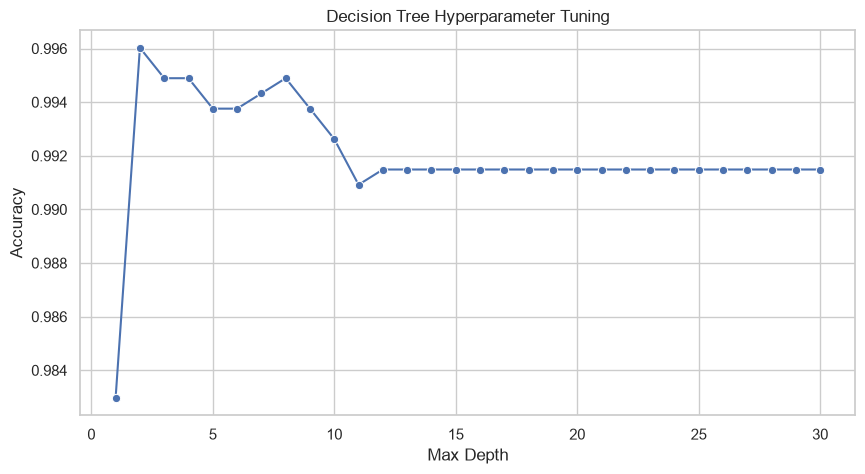

In [28]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=depth_df, x="max_depth", y="accuracy", marker="o")
plt.title("Decision Tree Hyperparameter Tuning")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.show()

In [29]:
best_depth = int(depth_df.sort_values(by="accuracy", ascending=False).iloc[0]["max_depth"])

dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_best.fit(X_train_tfidf, y_train)
dt_best_pred = dt_best.predict(X_test_tfidf)
dt_best_acc = accuracy_score(y_test, dt_best_pred)

print("Best max_depth:", best_depth)
print("Tuned Decision Tree Accuracy:", dt_best_acc)
print(classification_report(y_test, dt_best_pred))

Best max_depth: 2
Tuned Decision Tree Accuracy: 0.9960272417707151
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       0.99      1.00      0.99       535

    accuracy                           1.00      1762
   macro avg       0.99      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



# 15. KNN Classifier

KNN predicts the class by looking at the nearest examples. We test different values of K.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

k_results = []

for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_tfidf, y_train)
    pred = knn.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    
    k_results.append({
        "K": k,
        "Accuracy": acc
    })

k_df = pd.DataFrame(k_results)
k_df.sort_values(by="Accuracy", ascending=False).head()

,K,Accuracy
24,25,0.972191
20,21,0.971056
22,23,0.970488
23,24,0.968785
19,20,0.968218


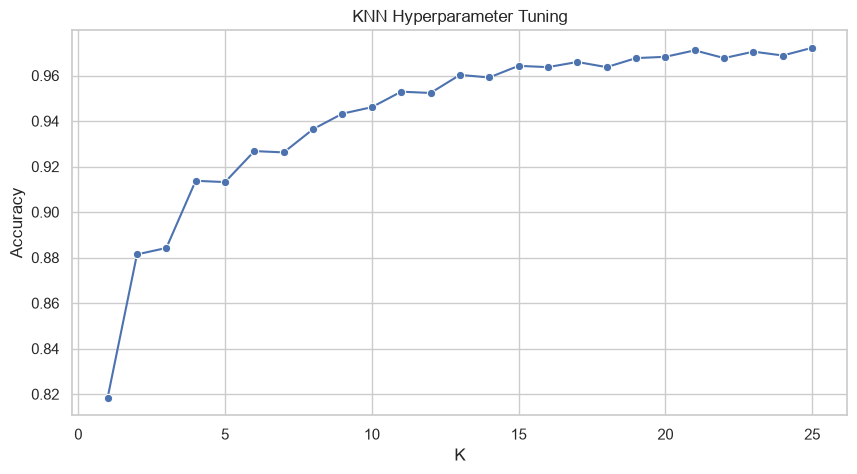

In [31]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=k_df, x="K", y="Accuracy", marker="o")
plt.title("KNN Hyperparameter Tuning")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [32]:
best_k = int(k_df.sort_values(by="Accuracy", ascending=False).iloc[0]["K"])

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_tfidf, y_train)
knn_pred = knn_final.predict(X_test_tfidf)
knn_acc = accuracy_score(y_test, knn_pred)

print("Best K:", best_k)
print("KNN Accuracy:", knn_acc)
print(classification_report(y_test, knn_pred))

Best K: 25
KNN Accuracy: 0.9721906923950057
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1227
           1       0.98      0.93      0.95       535

    accuracy                           0.97      1762
   macro avg       0.98      0.96      0.97      1762
weighted avg       0.97      0.97      0.97      1762



# 16. Model Comparison

Now we compare all models in one table.

In [33]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Tuned Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        baseline_acc,
        lr_acc,
        nb_acc,
        dt_acc,
        dt_best_acc,
        knn_acc
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)
results

,Model,Accuracy
4,Tuned Decision Tree,0.996027
3,Decision Tree,0.991487
1,Logistic Regression,0.990352
5,KNN,0.972191
2,Naive Bayes,0.963678
0,Baseline,0.696368


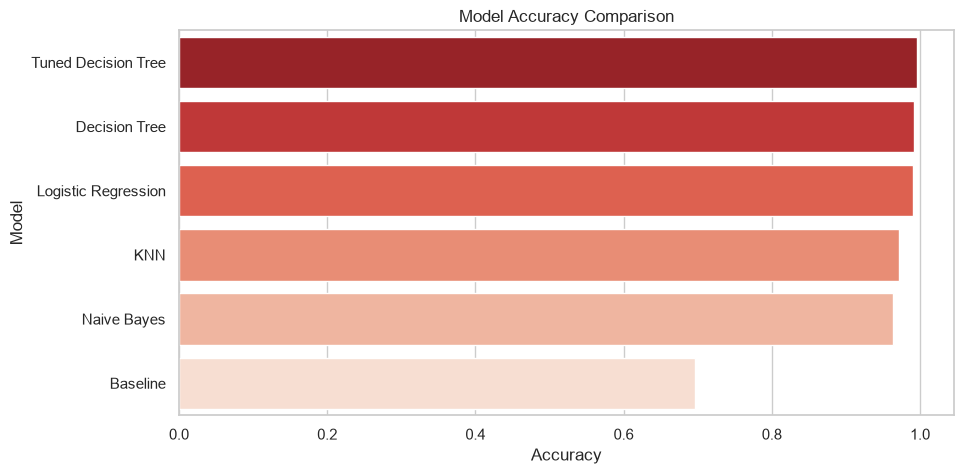

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Accuracy", y="Model", palette="Reds_r")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

## Machine Learning Conclusion

- The baseline model gives us a minimum performance benchmark.
- All real machine learning models performed better than the baseline.
- Logistic Regression and Decision Tree performed extremely well because the text features contain strong clues such as `TV Shows`, `Movies`, `Dramas`, and `Comedies`.
- KNN also performed well but can be slower on high-dimensional TF-IDF data.

# 17. Content-Based Recommendation System

Content-based recommendation suggests titles similar to a selected title using genre and description.


In [35]:
# Create recommendation text feature

df["content"] = (
    df["listed_in"].fillna("")
    + " "
    + df["description"].fillna("")
)

df[["title", "content"]].head()

,title,content
0,Dick Johnson Is Dead,Documentaries As her father nears the end of h...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Feuds, flirtations and ..."
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_rec = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = tfidf_rec.fit_transform(df["content"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Cosine Similarity Shape:", cosine_sim.shape)

TF-IDF Matrix Shape: (8807, 10000)
Cosine Similarity Shape: (8807, 8807)


In [37]:
def recommend_movies(title, n=10):
    """
    Recommend movies/shows similar to the selected title.
    """
    if title not in indices:
        return "Title not found in dataset."
    
    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:n+1]

    movie_indices = [i[0] for i in similarity_scores]

    return df.iloc[movie_indices][["title", "type", "listed_in", "description"]]

In [38]:
recommend_movies("Kota Factory")

,title,type,listed_in,description
3461,Cheese in the Trap,TV Show,"International TV Shows, Korean TV Shows, Roman...","In this adaptation of a popular webtoon, a poo..."
7632,"O-Negative, Love Can’t Be Designed",TV Show,"International TV Shows, Romantic TV Shows, TV ...",Five schoolmates who share a blood type naviga...
4265,Single Ladies Senior,TV Show,"International TV Shows, Romantic TV Shows, TV ...",Four best friends and spirited career women na...
2362,The Politician,TV Show,"TV Comedies, TV Dramas, Teen TV Shows",Rich kid Payton has always known he's going to...
8334,The Great Train Robbery,TV Show,"British TV Shows, Crime TV Shows, Internationa...",This two-part tale delivers the true story of ...
397,Feels Like Ishq,TV Show,"International TV Shows, Romantic TV Shows, TV ...",Short films follow young adults as they naviga...
805,Racket Boys,TV Show,"International TV Shows, TV Comedies, TV Dramas",A city kid is brought to the countryside by hi...
8165,Teresa,TV Show,"International TV Shows, Romantic TV Shows, Spa...","We all want so much more than we have, but how..."
3742,Somewhere Only We Know,TV Show,"International TV Shows, Romantic TV Shows, TV ...",A language major bickers with – and falls for ...
3845,Cinta 100KG,TV Show,"International TV Shows, Romantic TV Shows, TV ...","Two female friends, each with confidence issue..."


**Insight:** The recommender finds titles with similar genre and description patterns.

# 18. User-Item Matrix

The original dataset has no user ratings. To learn collaborative filtering, we create synthetic users and ratings.

In [39]:
np.random.seed(42)

num_users = 500
num_movies = len(df)
ratings_list = []

# Each synthetic user rates around 30 random movies/shows
for user_id in range(1, num_users + 1):
    rated_movies = np.random.choice(df.index, size=30, replace=False)
    
    for movie_id in rated_movies:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.05, 0.10, 0.20, 0.35, 0.30])
        ratings_list.append([user_id, movie_id, rating])

ratings_df = pd.DataFrame(
    ratings_list,
    columns=["user_id", "movie_id", "rating"]
)

ratings_df.head()

,user_id,movie_id,rating
0,1,4970,4
1,1,3362,3
2,1,5494,4
3,1,1688,4
4,1,1349,5


In [40]:
user_item_matrix = ratings_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating",
    fill_value=0
)

print("User-Item Matrix Shape:", user_item_matrix.shape)
user_item_matrix.head()

User-Item Matrix Shape: (500, 7242)


movie_id  0     1     3     4     6     7     9     10    13    14    16    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  17    18    19    20    21    22    23    24    25    27    29    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  30    32    33    34    35    36    37    38    39    40    42    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   4.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  43    44    45    46    47    48    50    51    52    53    54    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  55    56    57    58    59    60    62    63    64    67    69    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  70    71    72    73    75    76    77    78    79    80    81    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  82    83    84    85    86    87    88    89    90    91    93    \
user_id                                                                      
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

movie_id  94    95    96    97    98    99    101   102   103   105   106   \
user_id                                                                      
1          0.0 

**Meaning:** Rows are users, columns are movie IDs, and values are ratings.

# 19. Matrix Factorization using NMF

Matrix Factorization breaks the large user-item matrix into smaller hidden feature matrices.

In [41]:
from sklearn.decomposition import NMF

nmf_model = NMF(
    n_components=20,
    random_state=42,
    max_iter=500
)

user_features = nmf_model.fit_transform(user_item_matrix)
movie_features = nmf_model.components_

print("User features shape:", user_features.shape)
print("Movie features shape:", movie_features.shape)

User features shape: (500, 20)
Movie features shape: (20, 7242)


In [42]:
predicted_ratings = np.dot(user_features, movie_features)

predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

predicted_ratings_df.head()

movie_id      0         1         3         4         6         7     \
user_id                                                                
1         0.009367  0.000000  0.003058  0.000691  0.030671  0.001102   
2         0.000000  0.000000  0.002219  0.000000  0.000000  0.000000   
3         0.127895  0.191043  0.113900  0.755096  0.000090  0.002833   
4         0.006305  0.000000  0.000000  0.036469  0.006756  0.003429   
5         0.049364  0.043692  0.021487  0.141994  0.007575  0.012025   

movie_id      9         10        13        14        16        17    \
user_id                                                                
1         0.003523  0.001358  0.017856  0.002981  0.004691  0.028445   
2         0.001455  0.000000  0.000000  0.000000  0.040907  0.021175   
3         0.000000  0.000000  0.140225  0.000000  0.000000  0.000980   
4         0.016759  0.000000  0.000000  0.000000  0.002822  0.033867   
5         0.000694  0.004380  0.032550  0.000468  0.014042  0.003457   

movie_id      18        19        20        21        22        23    \
user_id                                                                
1         0.027701  0.012258  0.040163  0.000115  0.025866  0.008615   
2         0.000000  0.007266  0.030711  0.000015  0.000000  0.139635   
3         0.001300  0.276869  0.000017  0.019949  0.035261  0.208898   
4         0.003645  0.001206  0.002118  0.000281  0.000000  0.009482   
5         0.008052  0.059932  0.005396  0.005704  0.023107  0.058740   

movie_id      24        25        27        29        30        32    \
user_id                                                                
1         0.000000  0.009444  0.005594  0.005955  0.004176  0.038499   
2         0.000000  0.001088  0.023203  0.000000  0.003311  0.000000   
3         0.001939  0.000000  0.016656  0.005308  0.000132  0.000000   
4         0.001289  0.089041  0.001601  0.002619  0.005533  0.016976   
5         0.004335  0.008097  0.013144  0.009806  0.003318  0.010693   

movie_id      33        34        35        36        37        38    \
user_id                                                                
1         0.010203  0.025644  0.004862  0.006707  0.003431  0.001895   
2         0.006756  0.056130  0.009950  0.008396  0.001535  0.000176   
3         0.000000  0.024982  0.001243  0.006268  0.009124  0.004234   
4         0.011290  0.014097  0.047624  0.014031  0.001474  0.023487   
5         0.014219  0.025568  0.002105  0.002308  0.003356  0.001524   

movie_id      39        40        42        43        44        45    \
user_id                                                                
1         0.017995  0.013765  0.008989  0.005366  0.020258  0.018574   
2         0.025628  0.143486  0.093608  0.006717  0.000000  0.001747   
3         0.000000  0.015722  0.062032  0.005014  0.001220  0.002292   
4         0.041469  0.261255  0.006450  0.011225  0.042271  0.000121   
5         0.003681  0.007306  0.026291  0.001847  0.009716  0.006014   

movie_id      46        47        48        50        51        52    \
user_id                                                                
1         0.001505  0.006147  0.003392  0.017662  0.015611  0.001811   
2         0.015655  0.000117  0.000000  0.000000  0.000000  0.000000   
3         0.000540  0.000000  0.000000  0.000003  0.011006  0.007183   
4         0.001160  0.241812  0.000000  0.002584  0.000131  0.000000   
5         0.003392  0.000843  0.002724  0.017204  0.009713  0.003953   

movie_id      53    54        55        56        57        58        59    \
user_id                                                                      
1         0.001921   0.0  0.019457  0.000146  0.024849  0.010144  0.007113   
2         0.000000   0.0  0.018364  0.000000  0.000000  0.000105  0.006334   
3         0.003139   0.0  0.000000  2.578873  0.028903  0.003002  0.025706   
4         0.002783   0.0  0.030688  0.000946  0.000000  0.020999  0.013255 

# 20. Personalized Recommendations from Matrix Factorization

In [43]:
def recommend_for_user(user_id, n=10):
    """
    Recommend movies for an existing synthetic user.
    """
    user_predictions = predicted_ratings_df.loc[user_id]

    already_rated = ratings_df[
        ratings_df["user_id"] == user_id
    ]["movie_id"].values

    user_predictions = user_predictions.drop(labels=already_rated, errors="ignore")

    top_movie_ids = user_predictions.sort_values(ascending=False).head(n).index

    return df.iloc[top_movie_ids][["title", "type", "listed_in", "description"]]

In [44]:
recommend_for_user(1, n=10)

,title,type,listed_in,description
7403,Marauders,Movie,Action & Adventure,A series of high-stakes thefts at banks owned ...
7536,My Ex-Ex,Movie,"Comedies, Romantic Movies",A recently dumped attorney hires a psychic to ...
4303,Vanjagar Ulagam,Movie,"Dramas, International Movies, Thrillers",Shyam wakes to discover he's suspected in a mu...
2031,Cuties,Movie,"Dramas, International Movies",Eleven-year-old Amy starts to rebel against he...
8529,The Tiger Hunter,Movie,"Comedies, Dramas, Independent Movies","It's 1979, and engineer Sami is excited to lea..."
2548,Trial By Media,TV Show,"Crime TV Shows, Docuseries","In this true crime docuseries, some of the mos..."
2928,Good Time,Movie,"Dramas, Independent Movies, Thrillers","After spearheading an ill-fated bank robbery, ..."
3413,Verses of Love 2,Movie,"Dramas, Faith & Spirituality, International Mo...","Now a lecturer in Edinburgh, Fahri tries to be..."
3253,"Lorena, Light-Footed Woman",Movie,"Documentaries, International Movies, Sports Mo...",Lorena Ramírez of Mexico's Rarámuri community ...
2648,The House of Flowers,TV Show,"International TV Shows, Spanish-Language TV Sh...","In this dark comedy, a wealthy matriarch tries..."


# 21. New User Recommendation System

This section is useful for the Streamlit app. A new user rates 2–4 titles, and the system recommends similar titles.

In [45]:
def recommend_for_new_user(user_ratings, n=10):
    """
    user_ratings should be a dictionary.
    Example:
    {
        "Kota Factory": 5,
        "Blood & Water": 4,
        "Ganglands": 3
    }
    """
    liked_movie_indices = []

    for title, rating in user_ratings.items():
        if title in indices:
            liked_movie_indices.append(indices[title])
        else:
            print(f"{title} not found in dataset")

    if len(liked_movie_indices) == 0:
        return pd.DataFrame()

    similarity_scores = cosine_sim[liked_movie_indices]
    avg_similarity_scores = similarity_scores.mean(axis=0)

    scores = pd.Series(avg_similarity_scores, index=df.index)
    scores = scores.drop(labels=liked_movie_indices, errors="ignore")

    top_indices = scores.sort_values(ascending=False).head(n).index

    return df.loc[top_indices, ["title", "type", "listed_in", "description"]]

In [46]:
new_user = {
    "Kota Factory": 5,
    "Blood & Water": 4,
    "Ganglands": 3
}

recommend_for_new_user(new_user, n=10)

,title,type,listed_in,description
8165,Teresa,TV Show,"International TV Shows, Romantic TV Shows, Spa...","We all want so much more than we have, but how..."
3177,Triad Princess,TV Show,"Crime TV Shows, International TV Shows, Romant...",After jostling her way into a gig as a celebri...
7463,Miss Dynamite,TV Show,"Crime TV Shows, International TV Shows, Spanis...","Wealthy, beautiful Valentina falls in love, on..."
3976,The Eagle of El-Se'eed,TV Show,"Crime TV Shows, International TV Shows, TV Act...",A police officer and a drug lord become embroi...
7632,"O-Negative, Love Can’t Be Designed",TV Show,"International TV Shows, Romantic TV Shows, TV ...",Five schoolmates who share a blood type naviga...
2184,Get Even,TV Show,"British TV Shows, Crime TV Shows, Internationa...","In a secret act of skillful revenge, four priv..."
4271,Lion Pride,TV Show,"International TV Shows, Romantic TV Shows, TV ...","After crossing paths at a crime scene, a renow..."
2606,Extracurricular,TV Show,"Crime TV Shows, International TV Shows, Korean...",A model high school student who's steeped in a...
4487,Accidentally in Love,TV Show,"International TV Shows, Romantic TV Shows, TV ...","Rejecting the demands of her wealthy family, a..."
8334,The Great Train Robbery,TV Show,"British TV Shows, Crime TV Shows, Internationa...",This two-part tale delivers the true story of ...


# 22. Final Conclusion

This project completed an end-to-end Netflix recommendation workflow.

## What We Built

1. Cleaned and prepared Netflix data.
2. Performed EDA to understand Netflix content.
3. Created text features from title, genre, and description.
4. Built multiple classification models:
   - Baseline
   - Logistic Regression
   - Naive Bayes
   - Decision Tree
   - Tuned Decision Tree
   - KNN
5. Compared model performance.
6. Built a content-based recommendation system.
7. Created a synthetic user-item matrix.
8. Applied Matrix Factorization using NMF.
9. Built a new-user recommendation function for the Streamlit app.

## Future Improvements

- Add real user rating data.
- Add movie posters using TMDB API.
- Save users and ratings in a database.
- Deploy the Streamlit app online.
- Build hybrid recommendation using both content similarity and matrix factorization.

This project demonstrates data analysis, machine learning, NLP, recommendation systems, and frontend integration using Streamlit.
